### Normal Cumulative Probability Plot and Fit
For a set of values, display them in a normal cumulative probability plot and fit to normal distribution

In [1]:
#!pip install probscale  #for use in colab or Kaggle

In [2]:
import numpy as np, pandas as pd
from scipy.integrate import quad
from scipy.interpolate import splrep, splev # spline interprolation and point evaluation
from scipy.stats import linregress
import probscale, matplotlib.pyplot as plt

seed =  42
rng = np.random.default_rng(seed)

In [3]:
# Function for normal distribution pdf from wikipedia
def pdf_normal(z): return (1 / ((2 * np.pi))**0.5) * np.exp(-0.5 * (z**2))

# Percentile from z, integrate from neg infinity to z
def pcntl_from_z(z): return quad(pdf_normal, np.NINF, z)[0]

# z value from percentile by interpolating forward percentile from z
def z_from_pcntl(percentile):
    x = [pcntl_from_z(z) for z in np.arange(-7, 7.01, 0.01)]
    z = list(np.arange(-7, 7.01, 0.01))
    zspline = splrep(x, z)
    return splev(percentile, zspline)  #.item()

### Example input data

In [4]:
# Example Data: Make lognormal data
n_points = 8
normal_data_sim = rng.normal(0, 1, n_points) + 5
normal_pctl = 100 * np.array(range(1, n_points+1))/(n_points+1)

### Inputs

In [5]:
# Inputs
data = normal_data_sim
key_pctls = np.array([1, 10, 50, 90, 99])  # choose percentiles to evaluate on plot

### Normal fit of data

In [6]:
# Prep data
data_sorted = np.sort(data)
n_points = data.shape[0]
pctl = 100 * np.array(range(1, n_points+1))/(n_points+1)

In [7]:
# Linearize xy data
normal_data = data_sorted
ztile = z_from_pcntl(pctl/100)

In [8]:
# Regression of normalized data against z
slope, intercept, r_value, p_value, std_err = linregress(ztile, normal_data)

In [9]:
# Evaluate regression for key percentiles
key_pctls = key_pctls
key_ztile = z_from_pcntl(key_pctls/100)

reg_val_lst = [(z*slope + intercept) for z in key_ztile]

key_points_df = pd.DataFrame({'percentile': key_pctls, 'ztile': np.round(key_ztile,5), 'reg_val':reg_val_lst})
key_points_df

,percentile,ztile,reg_val
0,1,-2.32635,1.760392
1,10,-1.28155,3.075792
2,50,0.00000,4.689267
3,90,1.28155,6.302741
4,99,2.32635,7.618141


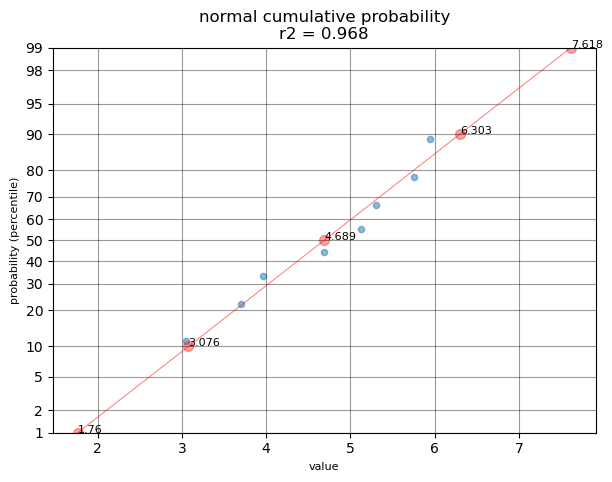

In [10]:
r2 = round(r_value**2, 3)

plt.figure(figsize=(7,5))
plt.scatter(data_sorted, pctl, alpha=0.5, s=20)
plt.scatter(key_points_df.reg_val, key_points_df.percentile, c='r', s=50, alpha=0.35)
plt.plot(key_points_df.reg_val, key_points_df.percentile, 'r-', alpha=0.5, linewidth=0.75)

for i in range(key_points_df.shape[0]):
    plt.annotate(round(key_points_df.reg_val[i], 3),
                (key_points_df.reg_val[i], key_points_df.percentile[i]),
                 fontsize=8)

plt.title(f"normal cumulative probability\nr2 = {r2}", fontsize=12)
plt.xlabel("value", fontsize=8)
plt.grid(color='black', alpha=0.4)
plt.grid(visible=True, which='minor')
plt.ylim(1, 99)
plt.yscale('prob')
plt.ylabel("probability (percentile)", fontsize=8)
plt.show()

In [11]:
# percentile - value dataframe of regression
percentile = np.array(range(1, 100))
ztile = z_from_pcntl(percentile/100)
regrssion_val_lst = [z*slope + intercept for z in ztile]
regress_df = pd.DataFrame({'percentile': percentile, 'reg_val': regrssion_val_lst })
display(regress_df.head(50))
display(regress_df.tail(49))

,percentile,reg_val
0,1,1.760392
1,2,2.103595
2,3,2.321345
3,4,2.485151
4,5,2.618394
5,6,2.731805
6,7,2.831244
7,8,2.920280
8,9,3.001255
9,10,3.075792


,percentile,reg_val
50,51,4.720828
51,52,4.752410
52,53,4.784031
53,54,4.815713
54,55,4.847474
55,56,4.879337
56,57,4.911322
57,58,4.943451
58,59,4.975746
59,60,5.008231
